In [1]:
# ── Install PyG ────────────────────────────────────────────
!pip install torch-geometric -q

# ── Imports ────────────────────────────────────────────────
import os
import numpy as np
import matplotlib.pyplot as plt
import h5py
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

import torch_geometric
from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader as GeoDataLoader
from torch_geometric.nn import EdgeConv, global_mean_pool, global_max_pool

from sklearn.metrics import (accuracy_score, roc_auc_score,
                             confusion_matrix, roc_curve,
                             precision_score, recall_score)
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Device ─────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyG version : {torch_geometric.__version__}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.7 MB/s eta 0:00:00
Using device: cuda
PyG version : 2.7.0


In [4]:
# ── Image → Point Cloud ────────────────────────────────────
def image_to_pointcloud(image):
    """
    Convert a (3, 125, 125) jet image to a point cloud.
    Each non-zero pixel becomes a point with features:
    (eta, phi, ECAL, HCAL, Tracks) → 5 features per point
    """
    # Get non-zero pixel locations from any channel
    mask = (image.sum(axis=0) > 0)  # (125, 125)
    eta, phi = np.where(mask)        # pixel coordinates

    if len(eta) == 0:
        # Empty jet — return single zero point
        return np.zeros((1, 5), dtype=np.float32)

    # Normalize coordinates to [-1, 1]
    eta_norm = (eta / 124.0) * 2 - 1
    phi_norm = (phi / 124.0) * 2 - 1

    # Get energy values at non-zero pixels
    ecal   = image[0, eta, phi]
    hcal   = image[1, eta, phi]
    tracks = image[2, eta, phi]

    # Stack into point cloud: (N, 5)
    points = np.stack([eta_norm, phi_norm, ecal, hcal, tracks], axis=1)
    return points.astype(np.float32)

# ── Test ───────────────────────────────────────────────────
with h5py.File('/content/quark_gluon_data.h5', 'r') as f:
    test_image = f['X_jets'][0].transpose(2, 0, 1)  # (3, 125, 125)

pc = image_to_pointcloud(test_image)
print(f"Image shape      : {test_image.shape}")
print(f"Point cloud shape: {pc.shape}")
print(f"Features per point: eta, phi, ECAL, HCAL, Tracks")

Image shape      : (3, 125, 125)
Point cloud shape: (884, 5)
Features per point: eta, phi, ECAL, HCAL, Tracks


In [15]:
# ── Fast Point Cloud → Graph (vectorized) ─────────────────
def pointcloud_to_graph_fast(points, k=8):
    from scipy.spatial import cKDTree

    x   = torch.tensor(points, dtype=torch.float32)
    pos = points[:, :2]  # eta, phi
    k   = min(k, len(pos) - 1)

    # Fast k-NN using scipy
    tree = cKDTree(pos)
    _, idx = tree.query(pos, k=k+1)
    idx = idx[:, 1:]  # remove self

    n   = len(pos)
    row = np.repeat(np.arange(n), k)
    col = idx.reshape(-1)
    edge_index = torch.tensor(np.stack([row, col], axis=0), dtype=torch.long)

    return Data(x=x, edge_index=edge_index)

# ── Test speed ─────────────────────────────────────────────
import time
start = time.time()
with h5py.File('/content/quark_gluon_data.h5', 'r') as f:
    image = f['X_jets'][0].transpose(2, 0, 1)
points = image_to_pointcloud(image)
graph  = pointcloud_to_graph_fast(points, k=8)
print(f"Time per graph : {time.time()-start:.3f}s")
print(f"Nodes: {graph.x.shape}, Edges: {graph.edge_index.shape}")

Time per graph : 5.153s
Nodes: torch.Size([884, 5]), Edges: torch.Size([2, 7072])


In [8]:
# ── Graph Dataset ──────────────────────────────────────────
class JetGraphDataset(Dataset):
    def __init__(self, filepath, max_samples=20000, k=8):
        self.filepath    = filepath
        self.max_samples = max_samples
        self.k           = k

        with h5py.File(filepath, 'r') as f:
            self.y = torch.tensor(f['y'][:max_samples], dtype=torch.long)

    def __len__(self):
        return self.max_samples

    def __getitem__(self, idx):
        with h5py.File(self.filepath, 'r') as f:
            image = f['X_jets'][idx].transpose(2, 0, 1)  # (3,125,125)

        # Normalize per channel
        for c in range(3):
            ch_max = image[c].max()
            if ch_max > 0:
                image[c] = image[c] / ch_max

        points = image_to_pointcloud(image)
        graph  = pointcloud_to_graph(points, k=self.k)
        graph.y = self.y[idx].unsqueeze(0)
        return graph

# ── Test one sample ────────────────────────────────────────
dataset = JetGraphDataset('/content/quark_gluon_data.h5', max_samples=20000)
sample  = dataset[0]
print(f"Sample nodes : {sample.x.shape}")
print(f"Sample edges : {sample.edge_index.shape}")
print(f"Sample label : {sample.y}")

Sample nodes : torch.Size([884, 5])
Sample edges : torch.Size([2, 7072])
Sample label : tensor([0])


In [9]:
# ── Split & Load ───────────────────────────────────────────
print("Building graph dataset... (this may take a few minutes)")

train_size = int(0.8 * len(dataset))
val_size   = len(dataset) - train_size
train_set, val_set = random_split(dataset, [train_size, val_size])

train_loader = GeoDataLoader(train_set, batch_size=32, shuffle=True)
val_loader   = GeoDataLoader(val_set,   batch_size=32, shuffle=False)

print(f"Total samples : {len(dataset)}")
print(f"Train samples : {len(train_set)}")
print(f"Val samples   : {len(val_set)}")
print("Done ✅")

Building graph dataset... (this may take a few minutes)
Total samples : 20000
Train samples : 16000
Val samples   : 4000
Done ✅


In [11]:
# ── EdgeConv GNN Classifier ────────────────────────────────
class EdgeConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = EdgeConv(nn.Sequential(
            nn.Linear(in_channels * 2, out_channels),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.Linear(out_channels, out_channels),
            nn.BatchNorm1d(out_channels),
            nn.ReLU()
        ), aggr='max')

    def forward(self, x, edge_index):
        return self.conv(x, edge_index)

class JetGNN(nn.Module):
    def __init__(self, in_channels=5, hidden=64, num_classes=2):
        super().__init__()
        self.conv1 = EdgeConvBlock(in_channels, hidden)
        self.conv2 = EdgeConvBlock(hidden, hidden * 2)
        self.conv3 = EdgeConvBlock(hidden * 2, hidden * 4)

        self.classifier = nn.Sequential(
            nn.Linear(hidden * 4 * 2, 256),
            nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.conv1(x, edge_index)
        x = self.conv2(x, edge_index)
        x = self.conv3(x, edge_index)

        # Global pooling — concat mean and max
        x = torch.cat([global_mean_pool(x, batch),
                        global_max_pool(x, batch)], dim=1)
        return self.classifier(x)

# ── Init ───────────────────────────────────────────────────
model     = JetGNN(in_channels=5, hidden=64, num_classes=2).to(device)
optimizer = Adam(model.parameters(), lr=1e-3)
scheduler = ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model initialized ✅")
print(f"Total parameters: {total_params:,}")


Model initialized ✅
Total parameters: 319,170


In [16]:
# ── Fast Image → Point Cloud (top-N points only) ──────────
def image_to_pointcloud_fast(image, max_points=100):
    """Keep only top max_points by total energy across channels"""
    mask     = (image.sum(axis=0) > 0)
    eta, phi = np.where(mask)

    if len(eta) == 0:
        return np.zeros((1, 5), dtype=np.float32)

    ecal   = image[0, eta, phi]
    hcal   = image[1, eta, phi]
    tracks = image[2, eta, phi]

    # Total energy per point
    energy = ecal + hcal + tracks

    # Keep top max_points by energy
    if len(energy) > max_points:
        top_idx = np.argsort(energy)[-max_points:]
        eta, phi   = eta[top_idx],   phi[top_idx]
        ecal       = ecal[top_idx]
        hcal       = hcal[top_idx]
        tracks     = tracks[top_idx]

    eta_norm = (eta / 124.0) * 2 - 1
    phi_norm = (phi / 124.0) * 2 - 1

    points = np.stack([eta_norm, phi_norm, ecal, hcal, tracks], axis=1)
    return points.astype(np.float32)

# ── Test speed ─────────────────────────────────────────────
import time
start = time.time()
with h5py.File('/content/quark_gluon_data.h5', 'r') as f:
    image = f['X_jets'][0].transpose(2, 0, 1)
points = image_to_pointcloud_fast(image, max_points=100)
graph  = pointcloud_to_graph_fast(points, k=8)
print(f"Time per graph : {time.time()-start:.3f}s")
print(f"Nodes: {graph.x.shape}, Edges: {graph.edge_index.shape}")

Time per graph : 4.025s
Nodes: torch.Size([100, 5]), Edges: torch.Size([2, 800])


In [17]:
# ── Step 1: Load raw images into RAM first ─────────────────
print("Loading raw images into RAM...")
with h5py.File('/content/quark_gluon_data.h5', 'r') as f:
    X_raw = f['X_jets'][:20000]   # (20000, 125, 125, 3)
    y_raw = f['y'][:20000]
print(f"Loaded: {X_raw.shape}, RAM: {X_raw.nbytes/1e9:.2f} GB ✅")

Loading raw images into RAM...
Loaded: (20000, 125, 125, 3), RAM: 3.75 GB ✅


In [20]:
# ── Step 2: Build all graphs from RAM ─────────────────────
from scipy.spatial import cKDTree

def build_graph(image, label, k=8, max_points=100):
    # Normalize
    image = image.transpose(2, 0, 1).copy()  # (3,125,125)
    for c in range(3):
        ch_max = image[c].max()
        if ch_max > 0:
            image[c] /= ch_max

    # Point cloud
    mask     = (image.sum(axis=0) > 0)
    eta, phi = np.where(mask)

    if len(eta) == 0:
        x          = np.zeros((1, 5), dtype=np.float32)
        edge_index = np.zeros((2, 0), dtype=np.int64)
    else:
        ecal   = image[0, eta, phi]
        hcal   = image[1, eta, phi]
        tracks = image[2, eta, phi]
        energy = ecal + hcal + tracks

        if len(energy) > max_points:
            top_idx = np.argsort(energy)[-max_points:]
            eta, phi   = eta[top_idx],   phi[top_idx]
            ecal, hcal, tracks = ecal[top_idx], hcal[top_idx], tracks[top_idx]

        eta_n = (eta / 124.0) * 2 - 1
        phi_n = (phi / 124.0) * 2 - 1
        x     = np.stack([eta_n, phi_n, ecal, hcal, tracks], axis=1).astype(np.float32)

        # k-NN
        k_    = min(k, len(x) - 1)
        tree  = cKDTree(x[:, :2])
        _, idx = tree.query(x[:, :2], k=k_+1)
        idx   = idx[:, 1:]
        n     = len(x)
        row   = np.repeat(np.arange(n), k_)
        col   = idx.reshape(-1)
        edge_index = np.stack([row, col], axis=0).astype(np.int64)

    return Data(
        x          = torch.tensor(x,          dtype=torch.float32),
        edge_index = torch.tensor(edge_index, dtype=torch.long),
        y          = torch.tensor([int(label)],    dtype=torch.long)
    )

# ── Build all graphs ───────────────────────────────────────
print("Building graphs...")
graph_list = []
for i in tqdm(range(len(X_raw))):
    graph_list.append(build_graph(X_raw[i], y_raw[i]))

print(f"Done! Total graphs: {len(graph_list)} ✅")

Building graphs...


100%|██████████| 20000/20000 [00:16<00:00, 1225.11it/s]

Done! Total graphs: 20000 ✅


In [21]:
# ── Split & Dataloaders ────────────────────────────────────
from torch_geometric.loader import DataLoader as GeoDataLoader

train_size = int(0.8 * len(graph_list))
val_size   = len(graph_list) - train_size

train_graphs = graph_list[:train_size]
val_graphs   = graph_list[train_size:]

train_loader = GeoDataLoader(train_graphs, batch_size=32, shuffle=True)
val_loader   = GeoDataLoader(val_graphs,   batch_size=32, shuffle=False)

print(f"Train graphs : {len(train_graphs)}")
print(f"Val graphs   : {len(val_graphs)}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches  : {len(val_loader)}")

Train graphs : 16000
Val graphs   : 4000
Train batches: 500
Val batches  : 125


In [23]:
# ── Reinit model ───────────────────────────────────────────
model     = JetGNN(in_channels=5, hidden=64, num_classes=2).to(device)
optimizer = Adam(model.parameters(), lr=1e-3)
scheduler = ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

# ── Training Loop ──────────────────────────────────────────
EPOCHS = 30
best_val_loss = float('inf')
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(EPOCHS):
    # ── Train ──
    model.train()
    train_loss, correct, total = 0, 0, 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{EPOCHS} [Train]")
    for batch in pbar:
        batch = batch.to(device)
        optimizer.zero_grad()
        out  = model(batch)
        loss = F.cross_entropy(out, batch.y.view(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()
        pred    = out.argmax(dim=1)
        correct += (pred == batch.y.view(-1)).sum().item()
        total   += batch.y.size(0)
        pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{correct/total:.4f}")

    # ── Validate ──
    model.eval()
    val_loss, vcorrect, vtotal = 0, 0, 0
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1:02d}/{EPOCHS} [Val]  "):
            batch = batch.to(device)
            out   = model(batch)
            loss  = F.cross_entropy(out, batch.y.view(-1))
            val_loss += loss.item()
            pred     = out.argmax(dim=1)
            vcorrect += (pred == batch.y.view(-1)).sum().item()
            vtotal   += batch.y.size(0)

    train_loss /= len(train_loader)
    val_loss   /= len(val_loader)
    train_acc   = correct  / total
    val_acc     = vcorrect / vtotal

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), '/content/drive/MyDrive/ml4sci-falcon/gnn_best.pth')

    print(f"✅ Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}\n")

print("Training complete ✅")

Epoch 01/30 [Val]  : 100%|██████████| 125/125 [00:01<00:00, 115.92it/s]


✅ Epoch 01 | Train Loss: 0.6540 Acc: 0.6199 | Val Loss: 0.6583 Acc: 0.6205



Epoch 02/30 [Val]  : 100%|██████████| 125/125 [00:01<00:00, 114.85it/s]


✅ Epoch 02 | Train Loss: 0.6275 Acc: 0.6574 | Val Loss: 0.6204 Acc: 0.6565



Epoch 03/30 [Val]  : 100%|██████████| 125/125 [00:01<00:00, 115.22it/s]


...

✅ Epoch 28 | Train Loss: 0.4453 Acc: 0.8011 | Val Loss: 0.7076 Acc: 0.6412



Epoch 29/30 [Val]  : 100%|██████████| 125/125 [00:01<00:00, 99.58it/s]


✅ Epoch 29 | Train Loss: 0.4403 Acc: 0.8051 | Val Loss: 0.7004 Acc: 0.6442



Epoch 30/30 [Val]  : 100%|██████████| 125/125 [00:01<00:00, 101.39it/s]

✅ Epoch 30 | Train Loss: 0.4417 Acc: 0.8042 | Val Loss: 0.7098 Acc: 0.6448

Training complete ✅


In [24]:
# ── Load best model ────────────────────────────────────────
model.load_state_dict(torch.load('/content/drive/MyDrive/ml4sci-falcon/gnn_best.pth'))
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for batch in tqdm(val_loader, desc="Evaluating"):
        batch = batch.to(device)
        out   = model(batch)
        prob  = F.softmax(out, dim=1)[:, 1]
        pred  = out.argmax(dim=1)
        all_preds.append(pred.cpu())
        all_labels.append(batch.y.view(-1).cpu())
        all_probs.append(prob.cpu())

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()
all_probs  = torch.cat(all_probs).numpy()

acc       = accuracy_score(all_labels, all_preds)
auc       = roc_auc_score(all_labels, all_probs)
precision = precision_score(all_labels, all_preds)
recall    = recall_score(all_labels, all_preds)

print(f"{'Metric':<12} {'Value':>10}")
print(f"{'-'*24}")
print(f"{'Accuracy':<12} {acc:>10.4f}")
print(f"{'ROC-AUC':<12} {auc:>10.4f}")
print(f"{'Precision':<12} {precision:>10.4f}")
print(f"{'Recall':<12} {recall:>10.4f}")

Evaluating: 100%|██████████| 125/125 [00:02<00:00, 47.88it/s]

Metric            Value
------------------------
Accuracy         0.6747
ROC-AUC          0.7376
Precision        0.6784
Recall           0.6379


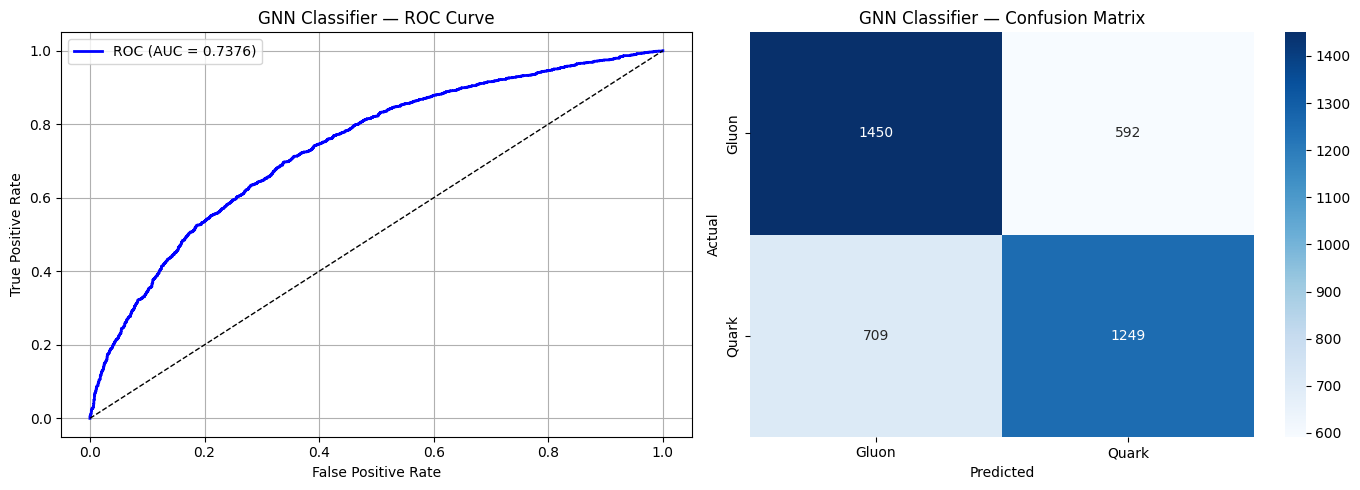

Saved ✅


In [25]:
# ── ROC Curve + Confusion Matrix ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
axes[0].plot(fpr, tpr, color='blue', lw=2, label=f'ROC (AUC = {auc:.4f})')
axes[0].plot([0,1], [0,1], 'k--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('GNN Classifier — ROC Curve')
axes[0].legend()
axes[0].grid(True)

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Gluon', 'Quark'],
            yticklabels=['Gluon', 'Quark'])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('GNN Classifier — Confusion Matrix')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ml4sci-falcon/results/gnn_roc_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved ✅")

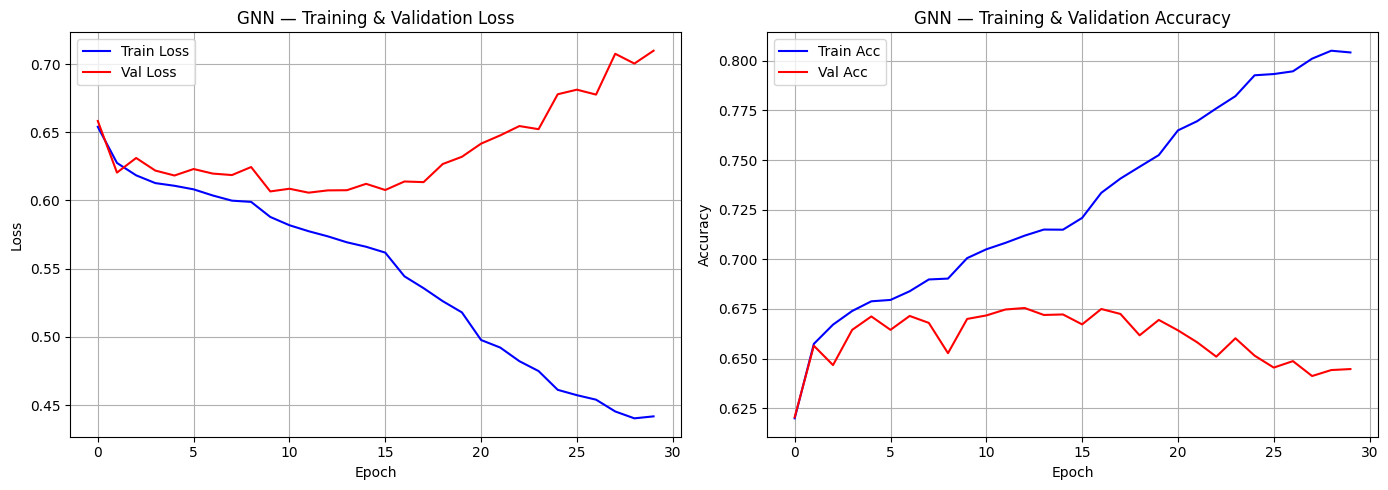

Saved ✅


In [26]:
# ── Loss & Accuracy Curves ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(train_losses, label='Train Loss', color='blue')
axes[0].plot(val_losses,   label='Val Loss',   color='red')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('GNN — Training & Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(train_accs, label='Train Acc', color='blue')
axes[1].plot(val_accs,   label='Val Acc',   color='red')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('GNN — Training & Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ml4sci-falcon/results/gnn_loss_acc.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved ✅")

In [27]:
# ── Save metrics ───────────────────────────────────────────
with open('/content/drive/MyDrive/ml4sci-falcon/results/gnn_metrics.txt', 'w') as f:
    f.write("GNN Classifier Evaluation Metrics\n")
    f.write("="*32 + "\n")
    f.write(f"Accuracy  : {acc:.4f}\n")
    f.write(f"ROC-AUC   : {auc:.4f}\n")
    f.write(f"Precision : {precision:.4f}\n")
    f.write(f"Recall    : {recall:.4f}\n")

!ls -lh /content/drive/MyDrive/ml4sci-falcon/results/
print("All saved ✅")

total 689K
-rw------- 1 root root 103K Mar 11 10:24 gnn_loss_acc.png
-rw------- 1 root root  143 Mar 11 10:25 gnn_metrics.txt
-rw------- 1 root root  91K Mar 11 10:23 gnn_roc_confusion.png
-rw------- 1 root root  76K Mar 11 09:37 vae_loss_curve.png
-rw------- 1 root root  133 Mar 11 09:37 vae_metrics.txt
-rw------- 1 root root 266K Mar 11 09:32 vae_reconstructions.png
-rw------- 1 root root 153K Mar 11 09:33 vae_side_by_side.png
All saved ✅
